<u>References:</u><br>
(1) https://medium.com/@piyushkashyap045/transfer-learning-in-pytorch-fine-tuning-pretrained-models-for-custom-datasets-6737b03d6fa2 <br>
(2) https://stackoverflow.com/questions/48630313/vgg16-trained-on-grayscale-imagenet/68393374#68393374 <br>
(3) https://medium.com/@piyushkashyap045/image-normalization-in-pytorch-from-tensor-conversion-to-scaling-3951b6337bc8 <br>

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, auc, roc_auc_score, RocCurveDisplay, precision_recall_curve, \
accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

import torch
from torch import optim
from torch import nn
from torch.utils.data import DataLoader
import torchvision
import torch.nn.functional as F
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torchvision.models as models
from torchsummary import summary

In [3]:
input_fpath = '/content/drive/MyDrive/chest_xray_resized_new_2'
output_fpath = '/content/drive/MyDrive/model_output'

In [4]:
def target_transform(x):
    return x

def load_datasets(train_path, val_path, test_path):
    # Pre-trained models expect inputs normalized to a specific range. Matching the normalization ensures consistency and better transfer learning performance.
    imagenet_mean = [0.485, 0.456, 0.406]
    imagenet_std = [0.229, 0.224, 0.225]
    val_img_transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=imagenet_mean, std=imagenet_std)])  # by default, transforms.ToTensor() will output 3 channels (make 3 identical copies of the original grayscale channel). VGG16 model which requires 3 channels
    train_img_transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=imagenet_mean, std=imagenet_std)])
    train_dataset = datasets.ImageFolder(train_path, transform=train_img_transform, target_transform = target_transform)
    val_dataset = datasets.ImageFolder(val_path, transform=val_img_transform, target_transform = target_transform)
    test_dataset = datasets.ImageFolder(test_path, transform=val_img_transform, target_transform = target_transform)
    print(f"Train set size: {len(train_dataset)}, Validation set size: {len(val_dataset)}, Test set size: {len(test_dataset)}")
    return train_dataset, val_dataset, test_dataset

In [5]:
# load all datasets
train_set, val_set, test_set = load_datasets(input_fpath + "/train", input_fpath + "/val", input_fpath + "/test")

Train set size: 6288, Validation set size: 1048, Test set size: 624


In [6]:
# response variable class labels
print(train_set.class_to_idx)
print(val_set.class_to_idx)
print(test_set.class_to_idx)

{'NORMAL': 0, 'PNEUMONIA': 1}
{'NORMAL': 0, 'PNEUMONIA': 1}
{'NORMAL': 0, 'PNEUMONIA': 1}


In [7]:
def construct_dataloaders(train_set, val_set, test_set, batch_size, shuffle=True):
    train_dataloader = torch.utils.data.DataLoader(train_set, batch_size, shuffle)
    val_dataloader = torch.utils.data.DataLoader(val_set, batch_size)
    test_dataloader = torch.utils.data.DataLoader(test_set, batch_size)
    return train_dataloader, val_dataloader, test_dataloader

In [8]:
# specify data loaders for VGG16 workflow
batch_size = 60
train_dataloader, val_dataloader, test_dataloader = construct_dataloaders(train_set, val_set, test_set, batch_size, True)

In [9]:
# device for running VGG16 model (GPU)
device = torch.device("cpu")

In [10]:
# Load the pre-trained VGG16 model
model = models.vgg16(weights='DEFAULT')

# Replace the output layer of the classifier part of the VGG16 model (the original model has 1000 out_features)
model.classifier[-1] = nn.Linear(in_features=model.classifier[-1].in_features, out_features=2) # for binary classification, out_features = 2

summary(model, input_size=(3, 224, 224), device="cpu")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 196MB/s]


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

In [11]:
# Freeze the weights in all layers except for those in the classifier layers
for param in model.parameters():
    param.requires_grad = False
for param in model.classifier.parameters():
    param.requires_grad = True

In [12]:
# Verify trainable vs. frozen parameters
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}  ({trainable_params/total_params*100:.2f}%)")
print(f"Frozen parameters:    {frozen_params:,}  ({frozen_params/total_params*100:.2f}%)")

Total parameters:     134,268,738
Trainable parameters: 119,554,050  (89.04%)
Frozen parameters:    14,714,688  (10.96%)


In [13]:
# Define the loss function
criterion = nn.CrossEntropyLoss() # suitable for classification tasks

# Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.00005) # a smaller learning rate is recommended for transfer learning (when fine-tuning lots of layers/weights in a pre-trained model)

In [14]:
class EarlyStopping:

    def __init__(self, patience=5, delta=0.01, path=output_fpath + '/checkpoint_vgg16_balanced.pt', verbose=True):
        '''
        An early stopping mechanism prevents CNN from overfitting the training data by monitering the change of the loss function on the validation set
        after each training epoch.
        '''
        self.patience = patience # how long to wait after the last best improvement before stopping
        self.delta = delta # the minimum change in validation loss that we care about
        self.path = path
        self.verbose = verbose
        self.best_loss = None
        self.no_improvement_count = 0

    def check_early_stop(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.no_improvement_count = 0
            # Save checkpoint if improvement observed
            torch.save(model.state_dict(), self.path)
            if self.verbose:
                print(f"Model improved; checkpoint saved at loss {val_loss:.4f}")
        else:
            self.no_improvement_count += 1
            if self.no_improvement_count >= self.patience:
                print("Early stopping triggered.")
                return True  # Signal to stop training
        return False

In [15]:
# Instantiate an early stopping controller
early_stopping = EarlyStopping(patience=5, delta=0.01)

In [16]:
# Training loop with early stopping and checkpointing
num_epochs = 100
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    # training within each epoch
    model.train() # Set model to training mode
    train_loss = 0.0
    print("Epoch {} Training...".format(epoch))
    for batch_idx, (data, target) in enumerate(train_dataloader):
        print("Batch", batch_idx)
        optimizer.zero_grad() # Reset parameter gradients to zero
        output = model(data) # Forward pass
        loss = criterion(output, target) # Compute the loss function for the batch
        loss.backward() # Back propogation
        optimizer.step() # Update weights
        train_loss += loss.item()
    train_losses.append(train_loss / len(train_dataloader)) # Loss function averaged over all batches

    # using validation set to monitor the model performance after each training epoch
    model.eval() # Set model to evaluation mode
    val_loss = 0.0
    print("Epoch {} Evaluation...".format(epoch))
    with torch.no_grad(): # This method disables the gradient calculation which reduces the memory consumption for computations
        for data, target in val_dataloader:
            output = model(data) # Forward pass
            loss = criterion(output, target) # Compute the loss function for the batch
            val_loss += loss.item()
    val_loss /= len(val_dataloader)
    val_losses.append(val_loss) # Loss function averaged over all batches

    # Early stopping check
    if early_stopping.check_early_stop(val_loss):
        print(f"Stopping training at epoch {epoch+1}")
        break

Epoch 0 Training...
Batch 0
Batch 1
Batch 2
Batch 3
Batch 4
Batch 5
Batch 6
Batch 7
Batch 8
Batch 9
Batch 10
Batch 11
Batch 12
Batch 13
Batch 14
Batch 15
Batch 16
Batch 17
Batch 18
Batch 19
Batch 20
Batch 21
Batch 22
Batch 23
Batch 24
Batch 25
Batch 26
Batch 27
Batch 28
Batch 29
Batch 30
Batch 31
Batch 32
Batch 33
Batch 34
Batch 35
Batch 36
Batch 37
Batch 38
Batch 39
Batch 40
Batch 41
Batch 42
Batch 43
Batch 44
Batch 45
Batch 46
Batch 47
Batch 48
Batch 49
Batch 50
Batch 51
Batch 52
Batch 53
Batch 54
Batch 55
Batch 56
Batch 57
Batch 58
Batch 59
Batch 60
Batch 61
Batch 62
Batch 63
Batch 64
Batch 65
Batch 66
Batch 67
Batch 68
Batch 69
Batch 70
Batch 71
Batch 72
Batch 73
Batch 74
Batch 75
Batch 76
Batch 77
Batch 78
Batch 79
Batch 80
Batch 81
Batch 82
Batch 83
Batch 84
Batch 85
Batch 86
Batch 87
Batch 88
Batch 89
Batch 90
Batch 91
Batch 92
Batch 93
Batch 94
Batch 95
Batch 96
Batch 97
Batch 98
Batch 99
Batch 100
Batch 101
Batch 102
Batch 103
Batch 104
Epoch 0 Evaluation...
Model improved; ch

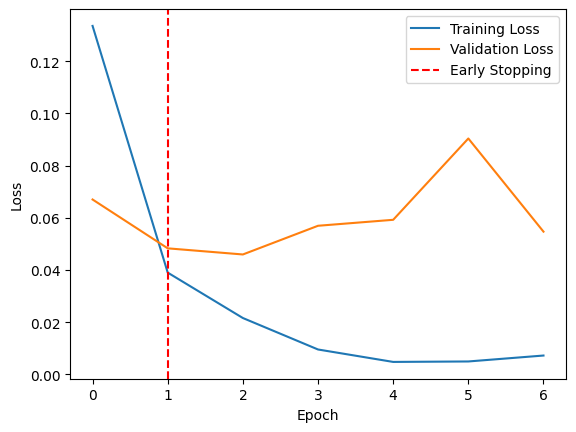

In [17]:
# Load best model checkpoint after early stopping
model.load_state_dict(torch.load(early_stopping.path))

# Final loss vs. epoch plot for both training and validation sets
epoch_list = np.arange(0, len(val_losses))
plt.plot(epoch_list, train_losses, label="Training Loss")
plt.plot(epoch_list, val_losses, label="Validation Loss")
plt.axvline(x=len(val_losses)-early_stopping.no_improvement_count-1, color='r', linestyle='--', label="Early Stopping")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [18]:
# Iterate over the test set batches to generate predicted probabilities for PNEUMONIA
model.eval() # Set model to evaluation mode
preds_list = []
y_list = []
with torch.no_grad(): # disabling the gradient calculation when evaluating model performance on test set
   for images, labels in test_dataloader:
       # Get predicted probabilities for test data batch
       outputs = model(images)
       # Convert the raw values in the output neurons to predicted probabilities:
       # dim is the dimension along which softmax will be computed. In this case, dim = 0 corresponds to indices for observations in the batch, dim = 1 corresponds to the raw output values of each observation
       preds = F.softmax(outputs, dim=1)
       preds_list.append(preds)
       y_list.append(labels)
pred_probabilities = torch.cat(preds_list, dim = 0).numpy()[:,1]
actual_y = torch.cat(y_list, dim = 0).numpy()

AUC = 0.9849


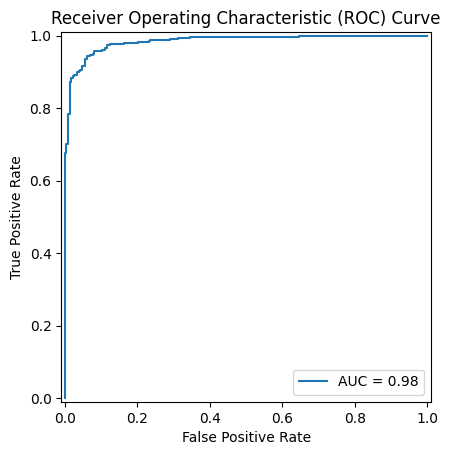

In [19]:
# ROC-AUC on test set
print("AUC =", round(roc_auc_score(actual_y, pred_probabilities), 4))
fpr, tpr, thresholds = roc_curve(actual_y, pred_probabilities)
roc_auc = auc(fpr, tpr)
display = RocCurveDisplay(tpr = tpr, fpr = fpr, roc_auc = roc_auc)
display.plot()
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.show()

In [20]:
# Tune the threshold via optimizing the F1 score of the minority class (using the validation set: balancing the tradeoff between precision and recall for the NORMAL class)
## Generate predicted probabilities for PNEUMONIA
model.eval() # Set model to evaluation mode
preds_list = []
y_list = []
with torch.no_grad():
   for images, labels in val_dataloader:
       # Get predicted probabilities for test data batch
       outputs = model(images)
       preds = F.softmax(outputs, dim=1)
       preds_list.append(preds)
       y_list.append(labels)
pred_probabilities_val = torch.cat(preds_list, dim = 0).numpy()[:,1]
actual_y_val = torch.cat(y_list, dim = 0).numpy()
## Get precision/recall/threshold values
precision, recall, thresholds = precision_recall_curve(1 - actual_y_val, 1 - pred_probabilities_val)
## Calculate F1 scores
f1_scores = 2 * recall * precision / (recall + precision)
## Find the threshold for the highest F1 score
best_idx = np.argmax(f1_scores)
best_threshold = 1 - thresholds[best_idx]
print("Best threshold =", best_threshold)

Best threshold = 0.61309314


Accuracy = 0.9119
Balanced accuracy = 0.8893
F1 score = 0.9328
True positive rate (sensitivity, recall) = 0.9795
True negative rate (specificity) = 0.7991
Positive predictive value (precision) = 0.8904
Negative predictive value = 0.959
Confusion matrix:


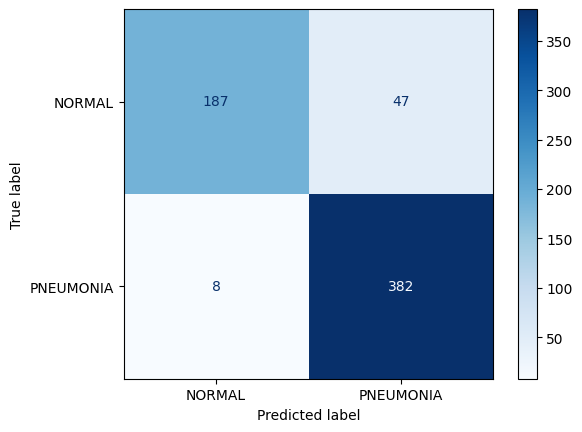

In [21]:
# Other evaluation metrics that depend on threshold:
pred_y = (pred_probabilities > best_threshold).astype(int)
print("Accuracy =", round(accuracy_score(actual_y, pred_y),4))
print("Balanced accuracy =", round(balanced_accuracy_score(actual_y, pred_y),4))
print("F1 score =", round(f1_score(actual_y, pred_y),4))
print("True positive rate (sensitivity, recall) =", round(recall_score(actual_y, pred_y),4))
print("True negative rate (specificity) =", round(recall_score(actual_y, pred_y, pos_label=0),4))
print("Positive predictive value (precision) =", round(precision_score(actual_y, pred_y),4))
print("Negative predictive value =", round(precision_score(actual_y, pred_y, pos_label=0),4))
print("Confusion matrix:")
cm = confusion_matrix(actual_y, pred_y, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NORMAL','PNEUMONIA'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [ ]:
# class MyDataset(Dataset):
#     def __getitem__(self, index):
#         data, target = self.data[index], self.targets[index]
#         # Explicitly return the index along with data
#         return data, target, index

# # Usage in training loop
# for batch_idx, (data, target, sample_indices) in enumerate(dataloader):
#     print(f"Indices in this batch: {sample_indices}")